# Análise dos Resultados

Este notebook executa os experimentos do trabalho, carrega os resultados salvos em `results/` e produz gráficos para apoiar a discussão do relatório.

In [2]:
from pathlib import Path
import sys

import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments import run_kmeans_experiment, run_kmeans_sklearn_comparison, run_knn_experiment, run_knn_sklearn_comparison

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
TRAIN_FILE = ROOT / 'nba_treino.csv'
TEST_FILE = ROOT / 'nba_teste.csv'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

In [3]:
knn_custom = run_knn_experiment(TRAIN_FILE, TEST_FILE, [2, 10, 50, 7], RESULTS_DIR / 'knn')
knn_sklearn = run_knn_sklearn_comparison(TRAIN_FILE, TEST_FILE, [2, 10, 50, 7], RESULTS_DIR / 'knn_sklearn')
kmeans_custom = run_kmeans_experiment(TRAIN_FILE, TEST_FILE, [2, 3], RESULTS_DIR / 'kmeans')
kmeans_sklearn = run_kmeans_sklearn_comparison(TRAIN_FILE, TEST_FILE, [2, 3], RESULTS_DIR / 'kmeans_sklearn')

len(knn_custom), len(knn_sklearn), len(kmeans_custom), len(kmeans_sklearn)

(4, 4, 2, 2)

In [4]:
knn_rows = []
for row in knn_custom:
    knn_rows.append({**row, 'origin': 'custom'})
for row in knn_sklearn:
    knn_rows.append({**row, 'origin': 'sklearn'})

knn_df = pd.DataFrame(knn_rows)
knn_df[['origin', 'k', 'accuracy', 'precision', 'recall', 'f1']]

,origin,k,accuracy,precision,recall,f1
0,custom,2,0.589552,0.754386,0.511905,0.609929
1,custom,10,0.652985,0.745098,0.678571,0.710280
2,custom,50,0.660448,0.722543,0.744048,0.733138
3,custom,7,0.649254,0.725610,0.708333,0.716867
4,sklearn,2,0.589552,0.754386,0.511905,0.609929
5,sklearn,10,0.652985,0.745098,0.678571,0.710280
6,sklearn,50,0.660448,0.722543,0.744048,0.733138
7,sklearn,7,0.649254,0.725610,0.708333,0.716867


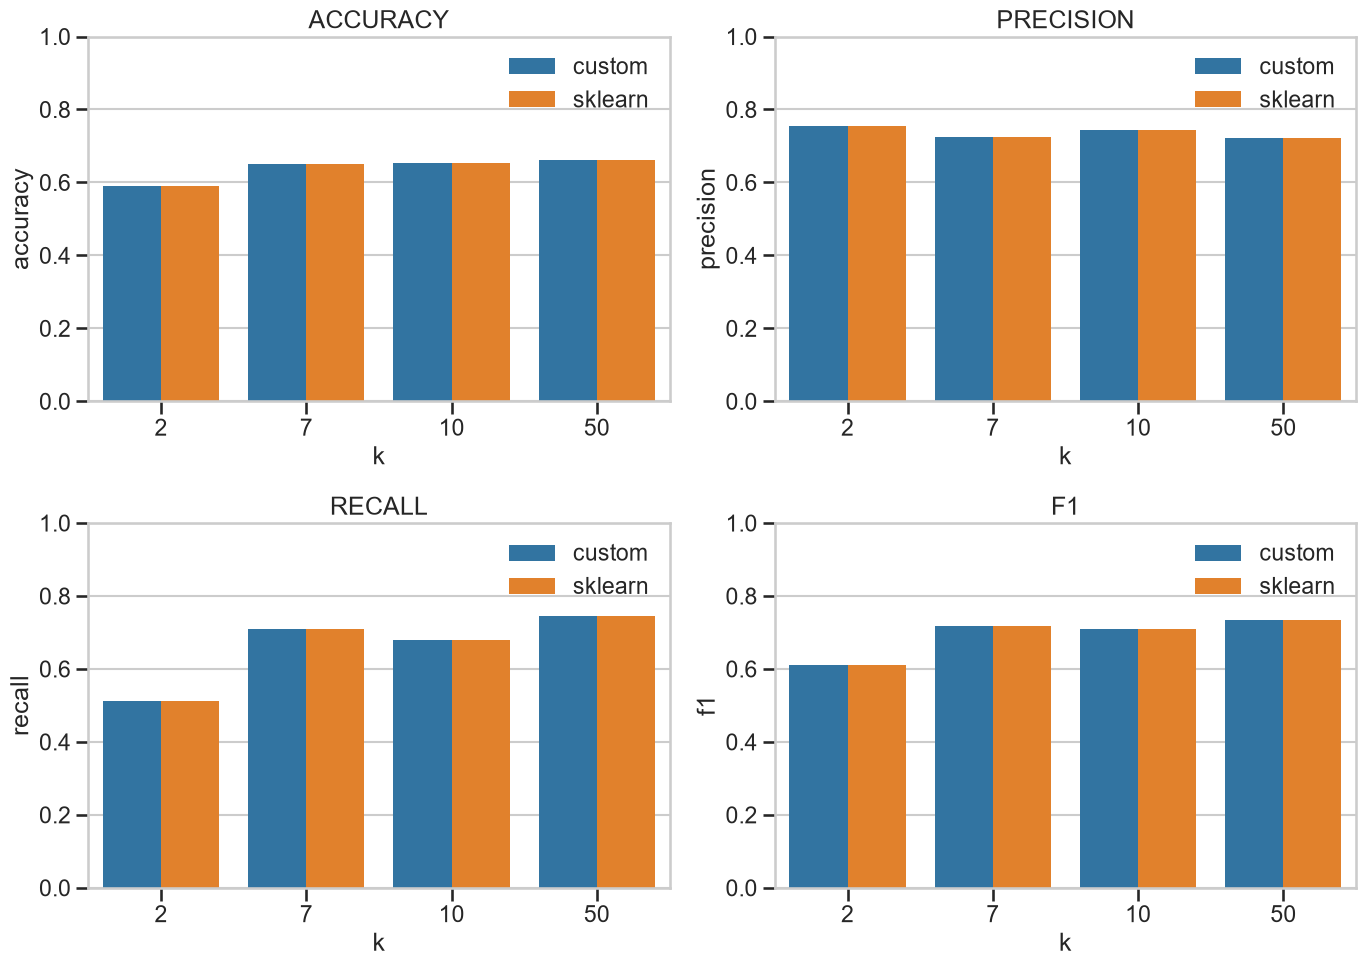

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']
for ax, metric in zip(axes.flat, metrics):
    sns.barplot(data=knn_df, x='k', y=metric, hue='origin', ax=ax)
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.legend(title='')
plt.tight_layout()

,pred_0,pred_1
true_0,72,28
true_1,82,86


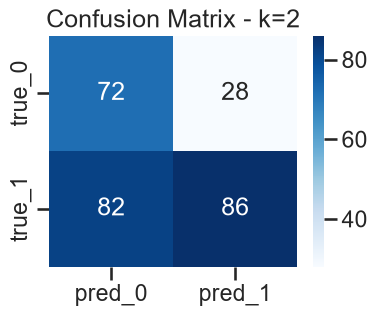

,pred_0,pred_1
true_0,61,39
true_1,54,114


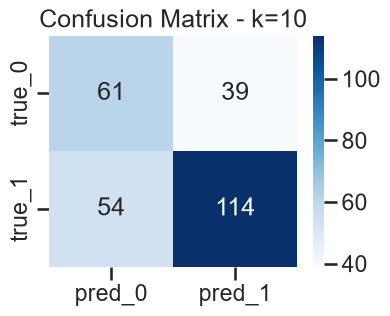

,pred_0,pred_1
true_0,52,48
true_1,43,125


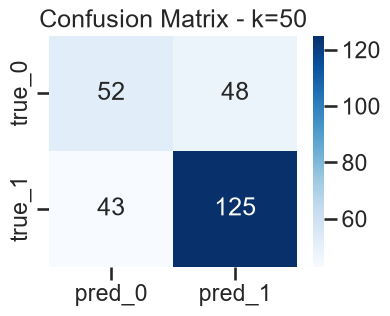

,pred_0,pred_1
true_0,55,45
true_1,49,119


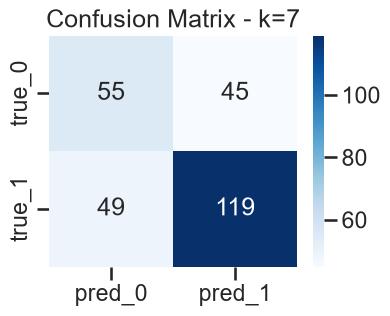

In [6]:
for result in knn_custom:
    matrix = pd.DataFrame(result['confusion_matrix'], index=['true_0', 'true_1'], columns=['pred_0', 'pred_1'])
    display(matrix)
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - k={result['k']}")
    plt.show()

In [7]:
kmeans_rows = []
for row in kmeans_custom:
    kmeans_rows.append({'origin': 'custom', 'k': row['k'], 'clusters': row['cluster_summary']})
for row in kmeans_sklearn:
    kmeans_rows.append({'origin': 'sklearn', 'k': row['k'], 'clusters': row['cluster_summary']})
kmeans_rows

[{'origin': 'custom',
  'k': 2,
  'clusters': {0: {0: 68, 1: 441}, 1: {0: 362, 1: 469}}},
 {'origin': 'custom',
  'k': 3,
  'clusters': {0: {0: 16, 1: 137, 2: 356}, 1: {0: 152, 1: 387, 2: 292}}},
 {'origin': 'sklearn',
  'k': 2,
  'clusters': {0: {0: 443, 1: 66}, 1: {0: 471, 1: 360}}},
 {'origin': 'sklearn',
  'k': 3,
  'clusters': {0: {0: 16, 1: 137, 2: 356}, 1: {0: 152, 1: 387, 2: 292}}}]

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.746469,1.174014,1.142876,1.136565,1.127279,0.301513,0.374881,0.386599,0.118506,1.018704,1.016872,0.236367,0.795592,0.926519,0.915052,0.724857,0.893325,0.567229,1.044701
1,-0.352727,-0.554754,-0.540040,-0.537058,-0.532670,-0.142473,-0.177141,-0.182679,-0.055997,-0.481366,-0.480500,-0.111690,-0.375939,-0.437806,-0.432387,-0.342515,-0.422121,-0.268031,-0.493650


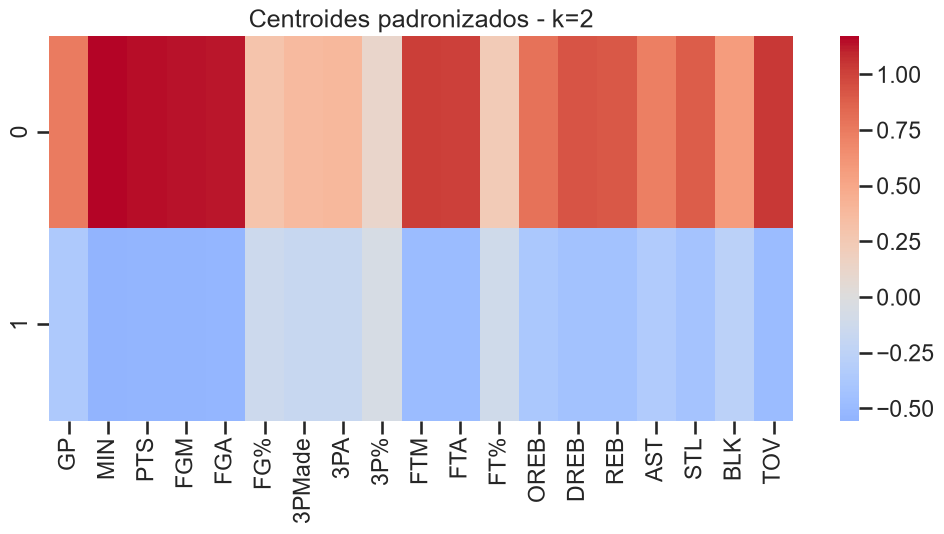

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.858803,1.798188,2.016208,1.987434,1.955273,0.375399,0.510607,0.550111,0.114687,1.919767,1.918791,0.278212,1.335713,1.572158,1.546132,1.170191,1.389122,0.996181,1.847498
1,0.560115,0.428424,0.252538,0.259283,0.255755,0.226546,0.161468,0.148526,0.104364,0.163814,0.163500,0.162648,0.229139,0.282307,0.271956,0.201434,0.322420,0.132434,0.225548
2,-0.675585,-0.812639,-0.726933,-0.724927,-0.713737,-0.280520,-0.262949,-0.262726,-0.114127,-0.630184,-0.629678,-0.203653,-0.531587,-0.635881,-0.620764,-0.466271,-0.620865,-0.365361,-0.661368


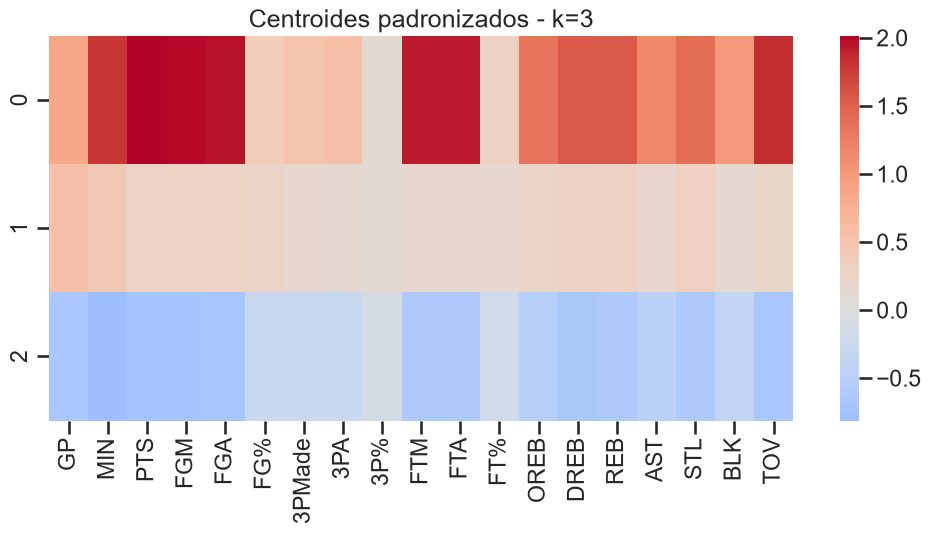

In [8]:
for result in kmeans_custom:
    centroid_df = pd.DataFrame(result['centroids_scaled'])
    display(centroid_df)
    plt.figure(figsize=(12, 5))
    sns.heatmap(centroid_df, annot=False, cmap='coolwarm', center=0)
    plt.title(f"Centroides padronizados - k={result['k']}")
    plt.show()